# GRA: signum

project = ```GRA```, host = ```chewie```, device = ```cuda:0```

## Goals:


In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Main

In [3]:
from optimzers import *
from test.test import *

### CIFAR10

`batch_size=256`

In [4]:
cfg = TrainConfig(
    dataset='CIFAR10',
    # dataset='ImageNet32',
    batch_size=256,
    epochs=50,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

In [5]:
lrs = [1e-4, 1e-3, 1e-2]
betas = [0.5, 0.7, 0.8, 0.9, 0.99]
masses = [0.0, 1, 10, 50, 100, 1000]

experiments = []
for lr, beta1, m in itertools.product(lrs, betas, masses):
    
    name = f"Rel. Signum — lr={lr:g},b1={beta1:g},mass={m:g}"
    opt_fn = make_opt(RelativisticSignum, lr=lr, momentum=beta1, mass=m)

    experiments.append(Experiment(name=name, opt_fn=opt_fn))

len(experiments)

90

In [ ]:
%%time


results = run_experiments(experiments, cfg=cfg, seeds=[0])

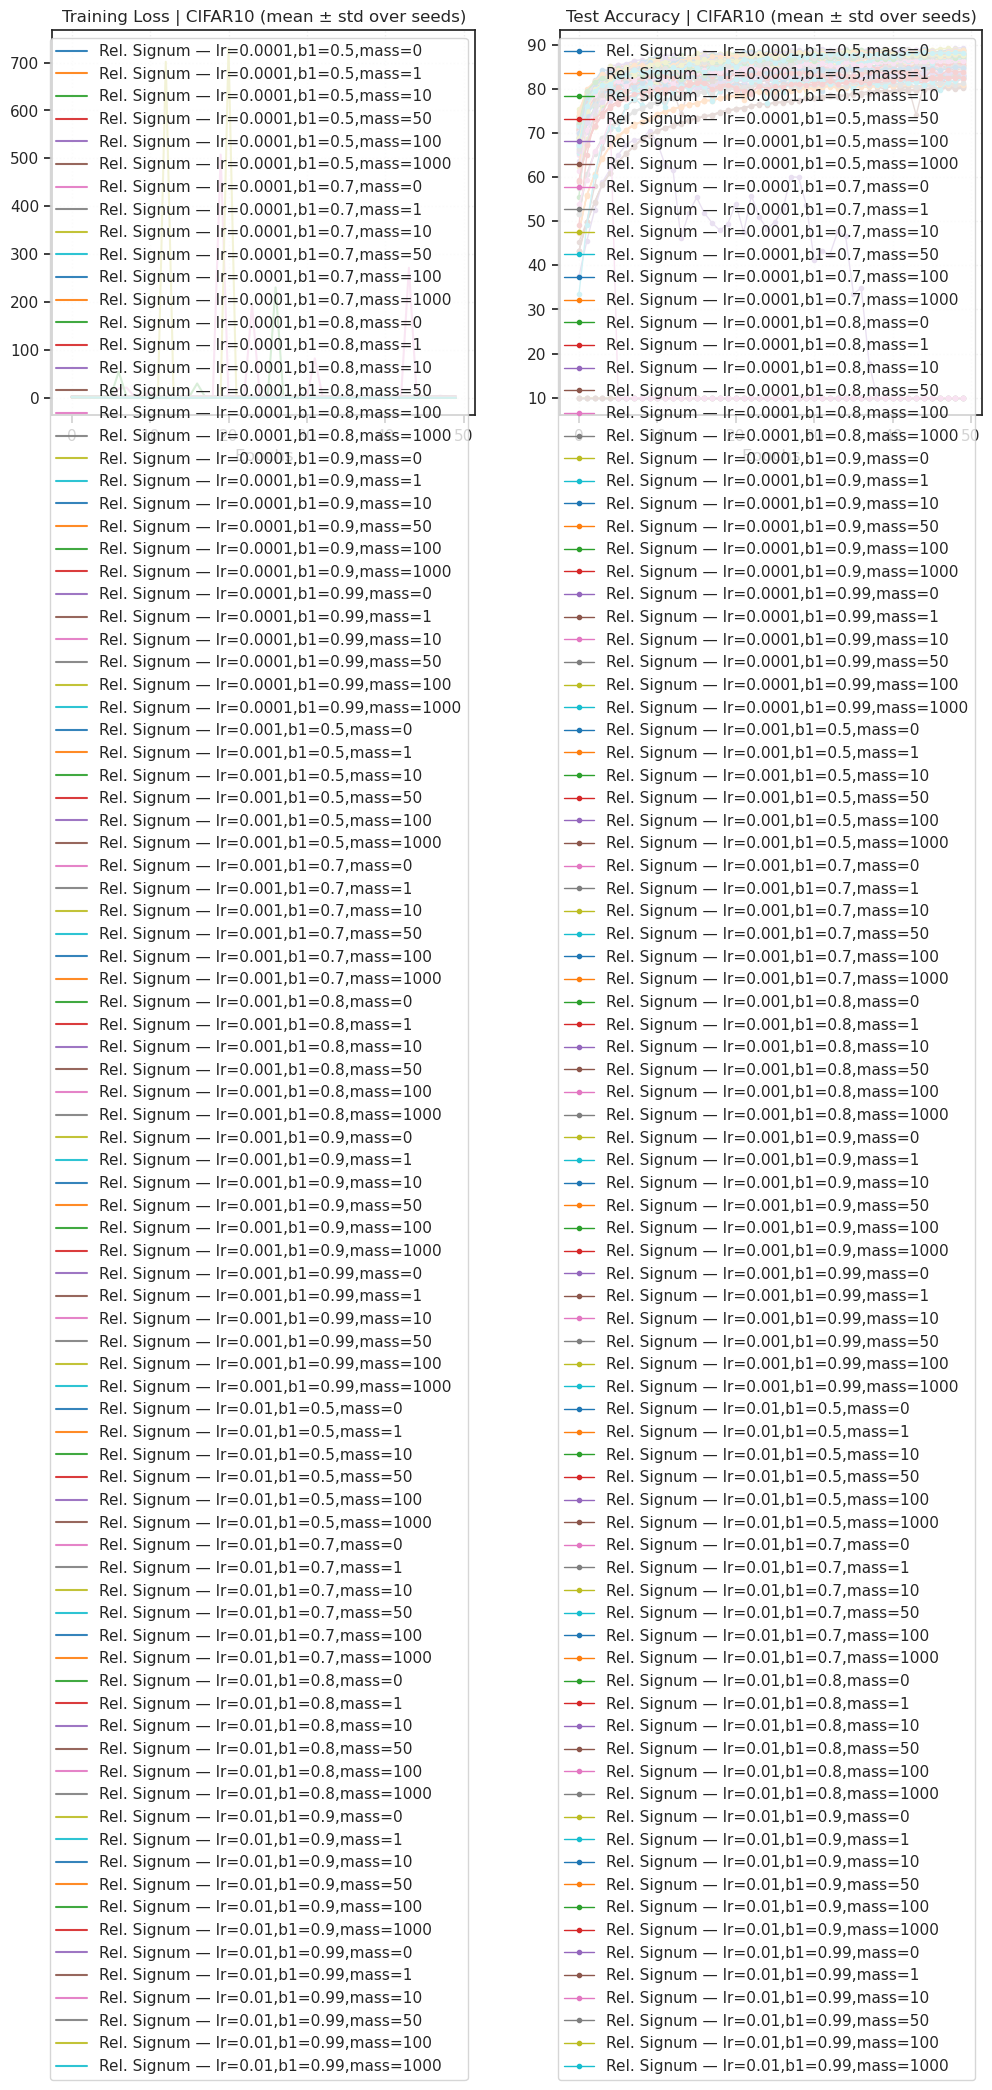

In [7]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

In [8]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Rel. Signum — lr=0.001,b1=0.99,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.5,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.7,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.8,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.9,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=1': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=10': 10.0,
 'Rel. Signum — lr=0.0001,b1=0.5,mass=1000': 80.02,
 'Rel. Signum — lr=0.001,b1=0.5,mass=1000': 80.32,
 'Rel. Signum — lr=0.01,b1=0.5,mass=1000': 80.33,
 'Rel. Signum — lr=0.0001,b1=0.7,mass=1000': 80.7,
 'Rel. Signum — lr=0.0001,b1=0.8,mass=1000': 80.75,
 'Rel. Signum — lr=0.001,b1=0.7,mass=1000': 80.93,
 'Rel. Signum — lr=0.01,b1=0.7,mass=1000': 81.0,
 'Rel. Signum — lr=0.01,b1=0.8,mass=1000': 81.06,
 'Rel. Signum — lr=0.001,b1=0.8,mass=1000': 81.2,
 'Rel. Signum — lr=0.01,b1=0.9,mass=1': 81.43,
 'Rel. Signum — lr=0.0001,b1=0.9,mass=1000': 81.99,
 'Rel. Signum — lr=0.0001,b1=0.5,mass=100': 82.01,
 'Rel. Signum — lr=0

In [120]:
def avg_scores_to_df(avg_scores: dict) -> pd.DataFrame:
    rows = []
    for k, score in avg_scores.items():
        key = str(k)

        # Split "XXX <dash> YYY" where dash may be em dash, en dash, or hyphen
        parts = re.split(r"\s*[—–-]\s*", key, maxsplit=1)
        optimizer = parts[0].strip()
        params_str = parts[1].strip() if len(parts) > 1 else ""

        params = {}
        if params_str:
            for item in params_str.split(","):
                item = item.strip()
                if not item or "=" not in item:
                    continue
                kk, vv = item.split("=", 1)
                kk = kk.strip()
                vv = vv.strip()

                # Best-effort numeric parse
                try:
                    if re.fullmatch(r"[+-]?\d+", vv):
                        vv_parsed = int(vv)
                    else:
                        vv_parsed = float(vv)
                except Exception:
                    vv_parsed = vv

                params[kk] = vv_parsed

        rows.append({
            "key": key,
            "optimizer": optimizer,
            "lr": params.get("lr", None),
            "b1": params.get("b1", None),
            "mass": params.get("mass", None),
            "score": float(score),
            **{f"param_{kk}": vv for kk, vv in params.items() if kk not in {"lr", "b1", "mass"}}
        })

    df = pd.DataFrame(rows)

    # Optional: nice ordering if those columns exist
    preferred = ["optimizer", "lr", "b1", "mass", "score", "key"]
    cols = [c for c in preferred if c in df.columns] + [c for c in df.columns if c not in preferred]
    return df[cols]


def _parse_mass_from_key(key: str):
    m = re.search(r"(?:^|,)\s*mass\s*=\s*([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)\s*(?:,|$)", key)
    if not m:
        return None
    v = float(m.group(1))
    return int(v) if v.is_integer() else v


def top_n_keys_by_mass(avg_scores: dict, masses: Sequence[float], num=5):
    out = {}
    for mass in masses:
        items = [
            (k, float(s))
            for k, s in avg_scores.items()
            if _parse_mass_from_key(str(k)) == mass
        ]
        items.sort(key=lambda x: x[1], reverse=True)
        out[mass] = [k for k, _ in items[:num]]
    return out

In [20]:
df = avg_scores_to_df(avg_scores)
df['lr'].unique()

array([0.001 , 0.01  , 0.0001])

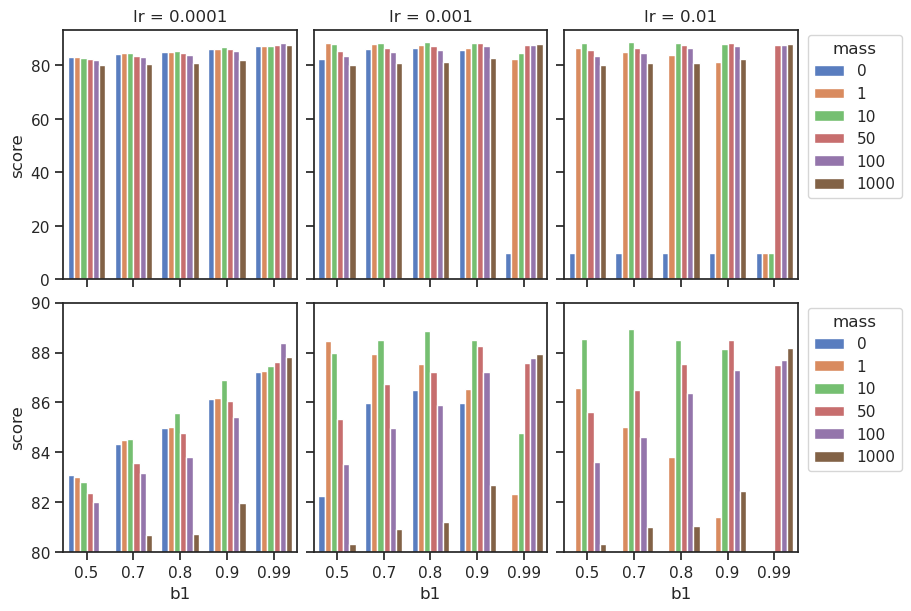

In [47]:
fig, axes = create_figure(2, 3, (9, 6), sharey='row', sharex='all')

for i, lr in enumerate(sorted(df['lr'].unique())):
    ax = axes[0, i]
    ax.set_title(f'lr = {lr}')
    _df2p = df.loc[df['lr'] == lr]
    sns.barplot(data=_df2p, hue='mass', y='score', x='b1', legend=i == 2, palette='muted', ax=ax)
    sns.barplot(data=_df2p, hue='mass', y='score', x='b1', legend=i == 2, palette='muted', ax=axes[1, i])

axes[1, 0].set_ylim(bottom=80, top=90)
move_legend(axes[0, 2], (1.01, 1.01))
move_legend(axes[1, 2], (1.01, 1.01))

plt.show()

In [60]:
selected_keys = top5_keys_by_mass(avg_scores, masses=[0, 10])
all_selected_keys = [k for mass in selected_keys for k in selected_keys[mass]]

print(selected_keys)

{
    0: [
        'Rel. Signum — lr=0.0001,b1=0.99,mass=0',
        'Rel. Signum — lr=0.001,b1=0.8,mass=0',
        'Rel. Signum — lr=0.0001,b1=0.9,mass=0',
        'Rel. Signum — lr=0.001,b1=0.7,mass=0',
        'Rel. Signum — lr=0.001,b1=0.9,mass=0'
    ],
    10: [
        'Rel. Signum — lr=0.01,b1=0.7,mass=10',
        'Rel. Signum — lr=0.001,b1=0.8,mass=10',
        'Rel. Signum — lr=0.01,b1=0.5,mass=10',
        'Rel. Signum — lr=0.001,b1=0.9,mass=10',
        'Rel. Signum — lr=0.001,b1=0.7,mass=10'
    ]
}

In [61]:
selected_results_to_plot = {
    k: d for k, d in results.items()
    if k in all_selected_keys
}

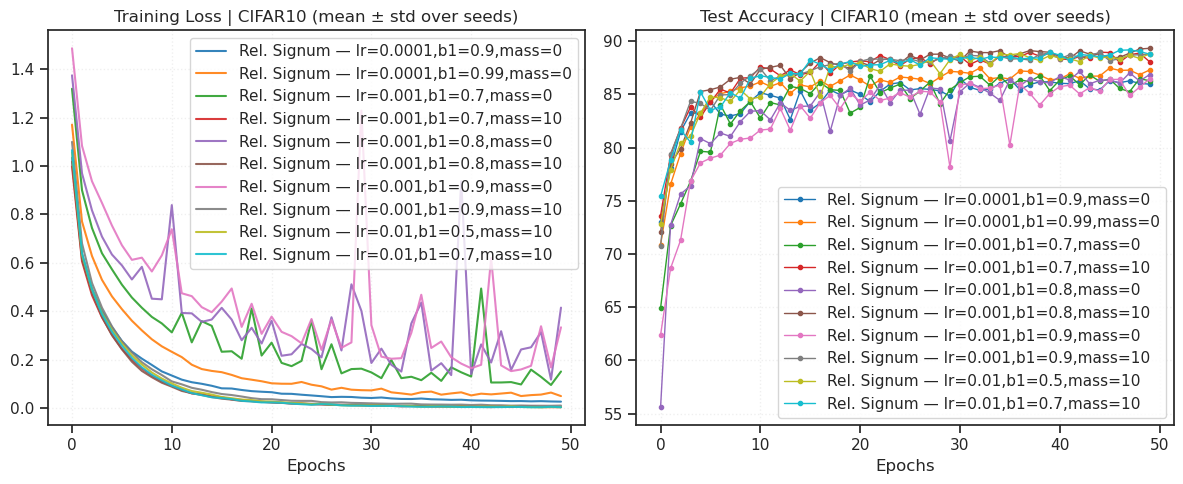

In [63]:
plot_results(selected_results_to_plot, title="CIFAR10 (mean ± std over seeds)")

## Add true signum (with dampening)

In [68]:
lrs = [1e-4, 1e-3, 1e-2]
betas = [0.0, 0.5, 0.7, 0.8, 0.9, 0.99]
dampening = [0.0, 0.1, 0.2, 0.5]

experiments = []
for lr, beta1, damp in itertools.product(lrs, betas, dampening):
    
    name = f"Signum — lr={lr:g},b1={beta1:g},m={damp:g}"
    opt_fn = make_opt(SignSGD, lr=lr, momentum=beta1, dampening=damp)

    experiments.append(Experiment(name=name, opt_fn=opt_fn))

len(experiments)

72

In [ ]:
%%time


results_signum = run_experiments(experiments, cfg=cfg, seeds=[0])

In [70]:
combined = results | results_signum

In [94]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in combined.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Rel. Signum — lr=0.001,b1=0.99,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.5,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.7,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.8,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.9,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=1': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=10': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0.5': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0.5': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0.5': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0.5': 

In [106]:
best_key, best_score = list(avg_scores.items())[
    np.argmax(list(avg_scores.values()))]

print(f"best fit:\t{best_key}\nbest score:\t{best_score} %")

best fit:       Rel. Signum — lr=0.01,b1=0.7,mass=10
best score:     88.96 %

In [107]:
df = avg_scores_to_df(avg_scores)
df['optimizer'].unique()

array(['Rel. Signum', 'Signum'], dtype=object)

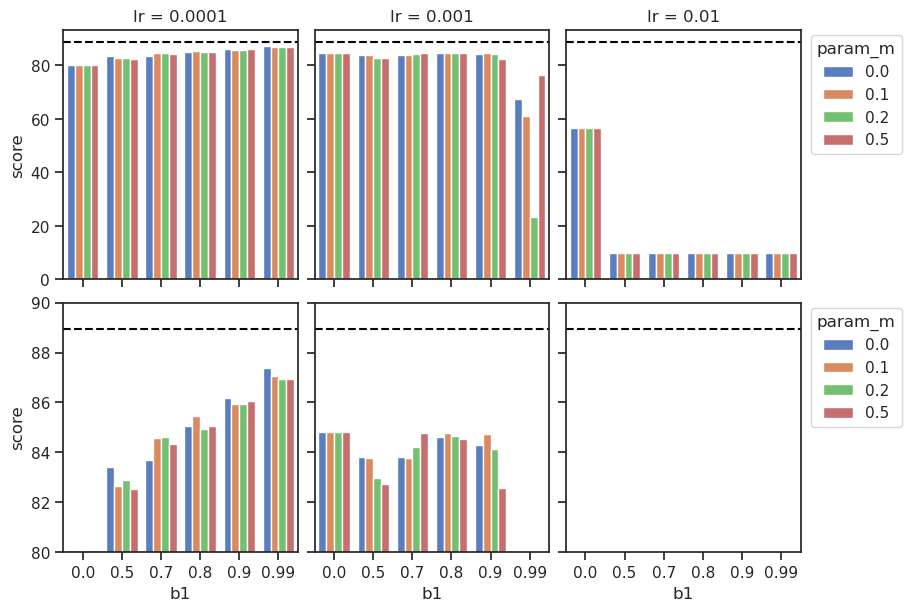

In [115]:
fig, axes = create_figure(2, 3, (9, 6), sharey='row', sharex='all')

for i, lr in enumerate(sorted(df['lr'].unique())):
    ax = axes[0, i]
    ax.set_title(f'lr = {lr}')
    
    _df2p = df.loc[(df['lr'] == lr) & (df['optimizer'] == 'Signum')]
    
    sns.barplot(data=_df2p, hue='param_m', y='score', x='b1', legend=i == 2, palette='muted', ax=ax)
    sns.barplot(data=_df2p, hue='param_m', y='score', x='b1', legend=i == 2, palette='muted', ax=axes[1, i])
    
    ax.axhline(best_score, color='k', ls='--')
    axes[1, i].axhline(best_score, color='k', ls='--')

axes[1, 0].set_ylim(bottom=80, top=90)
move_legend(axes[0, 2], (1.01, 1.01))
move_legend(axes[1, 2], (1.01, 1.01))

plt.show()

In [146]:
top_5_signum = {k: v for k, v in avg_scores.items() if k.startswith('Signum')}
top_5_signum = dict(sorted(list(top_3_signum.items()), key=lambda t: t[1], reverse=True)[:5])
print(top_5_signum)

{
    'Signum — lr=0.0001,b1=0.99,m=0': 87.39,
    'Signum — lr=0.0001,b1=0.99,m=0.1': 87.06,
    'Signum — lr=0.0001,b1=0.99,m=0.2': 86.96
}

In [150]:
selected_keys_rel = top_n_keys_by_mass(avg_scores, masses=[0, 10], num=5)
all_selected_keys = [k for mass in selected_keys_rel for k in selected_keys[mass]]
all_selected_keys += list(top_5_signum)

print(all_selected_keys)

[
    'Rel. Signum — lr=0.0001,b1=0.99,mass=0',
    'Rel. Signum — lr=0.001,b1=0.8,mass=0',
    'Rel. Signum — lr=0.0001,b1=0.9,mass=0',
    'Rel. Signum — lr=0.01,b1=0.7,mass=10',
    'Rel. Signum — lr=0.001,b1=0.8,mass=10',
    'Rel. Signum — lr=0.01,b1=0.5,mass=10',
    'Signum — lr=0.0001,b1=0.99,m=0',
    'Signum — lr=0.0001,b1=0.99,m=0.1',
    'Signum — lr=0.0001,b1=0.99,m=0.2'
]

In [153]:
selected_results_to_plot = {
    k: d for k, d in combined.items()
    if k in all_selected_keys
}

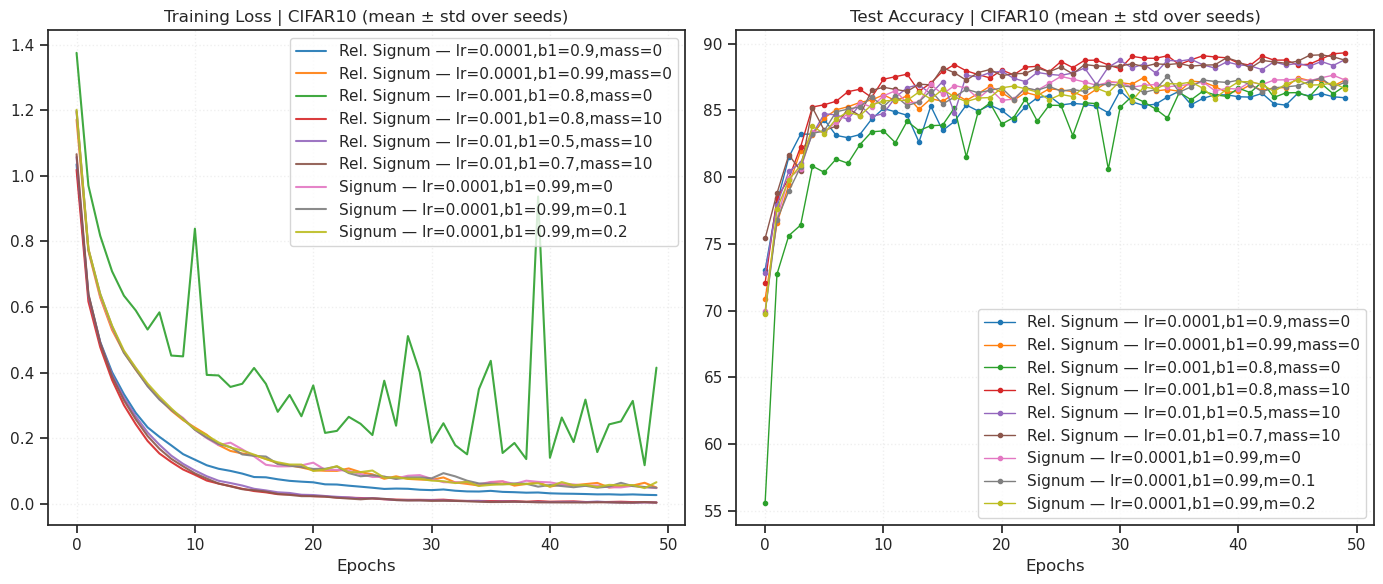

In [156]:
plot_results(selected_results_to_plot, title="CIFAR10 (mean ± std over seeds)", figsize=(14, 6))

## Explore the mass parameter better

In [157]:
lrs = [1e-3, 1e-2]
betas = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.99]
masses = [5, 10, 15, 20]

experiments = []
for lr, beta1, m in itertools.product(lrs, betas, masses):
    
    name = f"Rel. Signum — lr={lr:g},b1={beta1:g},mass={m:g}"
    opt_fn = make_opt(RelativisticSignum, lr=lr, momentum=beta1, mass=m)
    
    experiments.append(Experiment(name=name, opt_fn=opt_fn))

len(experiments)

56

In [158]:
%%time


results_explore_mass_param = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticSignum

RelativisticSignum (
Parameter Group 0
    lr: 0.001
    mass: 5
    momentum: 0.0
    weight_decay: 0.0
)

Epoch    1/50:  Train Loss 1.1421  |  Test Acc 71.74%

Epoch    2/50:  Train Loss 0.6814  |  Test Acc 77.01%

Epoch    3/50:  Train Loss 0.5286  |  Test Acc 80.64%

...

Epoch   48/50:  Train Loss 0.0632  |  Test Acc 84.24%

Epoch   49/50:  Train Loss 0.0690  |  Test Acc 84.54%

Epoch   50/50:  Train Loss 0.0557  |  Test Acc 83.62%

Finished in 165.3s

CPU times: user 2h 34min 17s, sys: 21.9 s, total: 2h 34min 39s
Wall time: 2h 34min 23s


In [159]:
all_results_so_far = combined | results_explore_mass_param

In [160]:
avg_scores = {
    k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2)
    for k, d in all_results_so_far.items()
}

avg_scores = dict(sorted(
    avg_scores.items(),
    key=lambda t: t[1],
))

avg_scores

{'Rel. Signum — lr=0.001,b1=0.99,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.5,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.7,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.8,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.9,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=0': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=1': 10.0,
 'Rel. Signum — lr=0.01,b1=0.99,mass=10': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.5,m=0.5': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.7,m=0.5': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.8,m=0.5': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0.1': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0.2': 10.0,
 'Signum — lr=0.01,b1=0.9,m=0.5': 

In [167]:
df = avg_scores_to_df(avg_scores)

print(df['optimizer'].unique())
print(df['mass'].unique())
print(df['b1'].unique())

['Rel. Signum' 'Signum']

[   0.    1.   10.   nan    5.   15. 1000.  100.   50.   20.]

[0.99 0.5  0.7  0.8  0.9  0.   0.3 ]

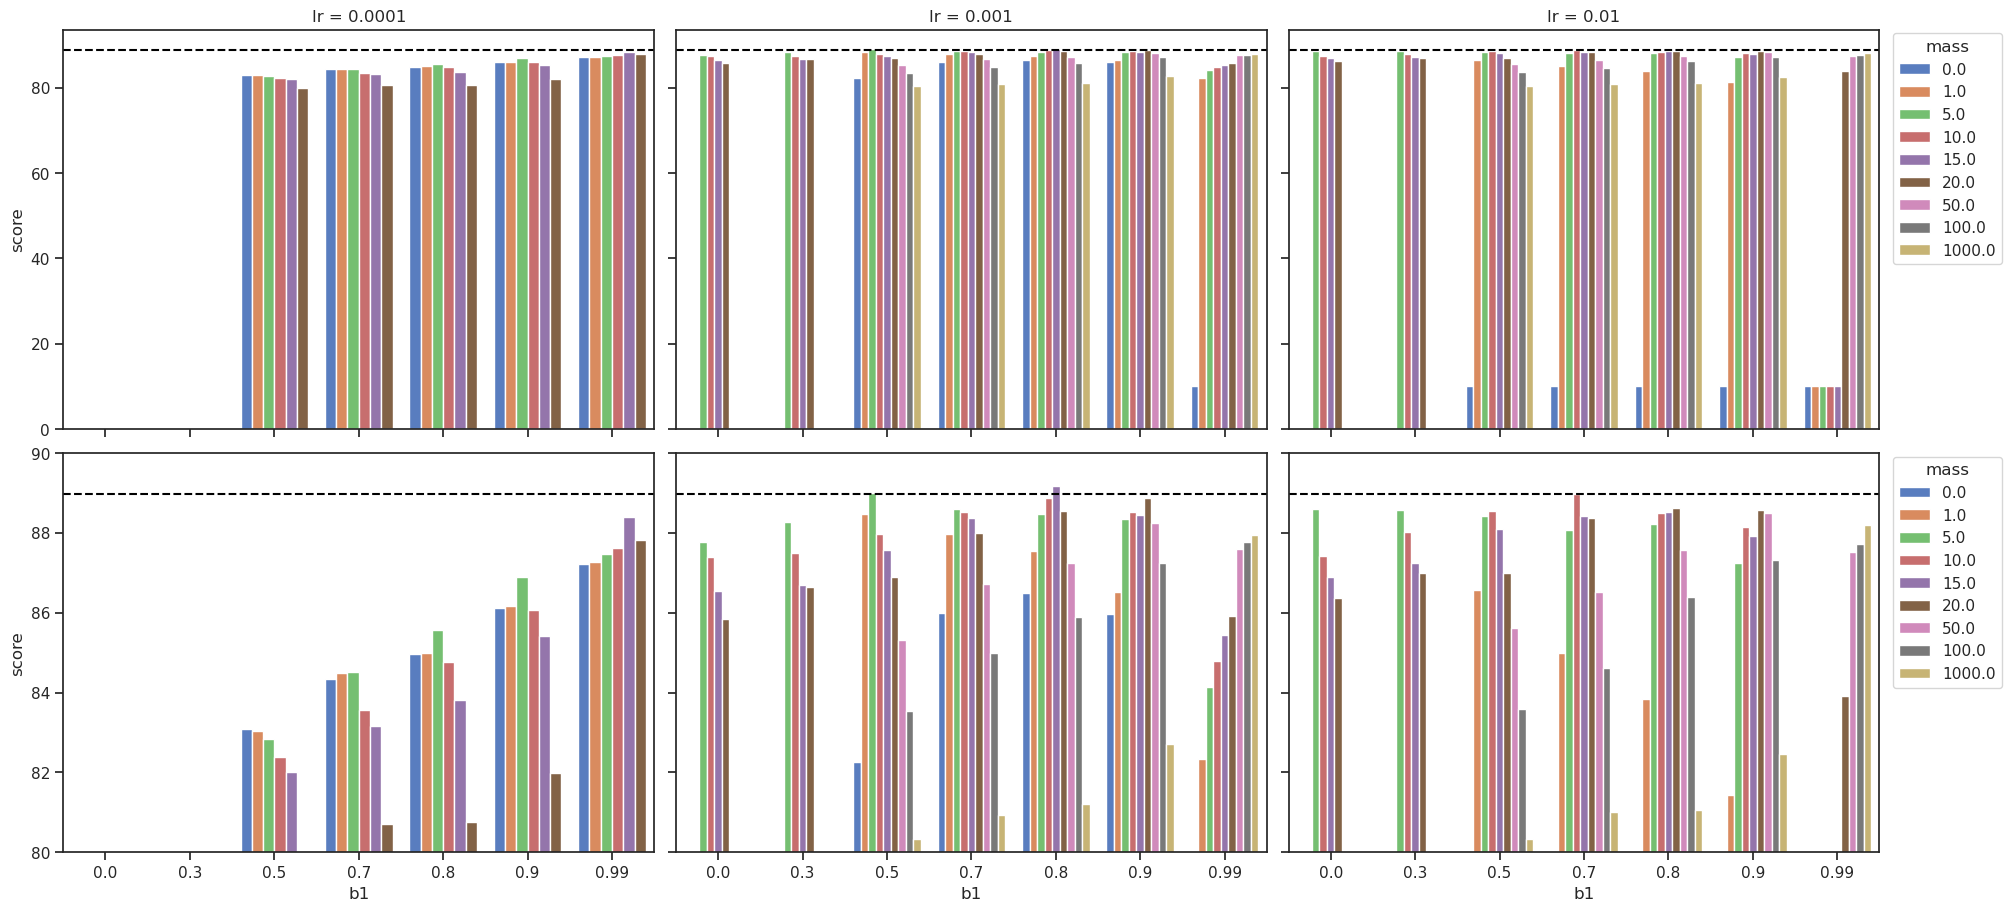

In [171]:
fig, axes = create_figure(2, 3, (20, 9), sharey='row', sharex='all')

for i, lr in enumerate(sorted(df['lr'].unique())):
    ax = axes[0, i]
    ax.set_title(f'lr = {lr}')
    
    _df2p = df.loc[(df['lr'] == lr) & (df['optimizer'] == 'Rel. Signum')]
    
    sns.barplot(data=_df2p, hue='mass', y='score', x='b1',
                order=sorted(df['b1'].unique()), legend=i == 2, palette='muted', ax=ax)
    sns.barplot(data=_df2p, hue='mass', y='score', x='b1',
                order=sorted(df['b1'].unique()), legend=i == 2, palette='muted', ax=axes[1, i])
    
    ax.axhline(best_score, color='k', ls='--')
    axes[1, i].axhline(best_score, color='k', ls='--')

axes[1, 0].set_ylim(bottom=80, top=90)
move_legend(axes[0, 2], (1.01, 1.01))
move_legend(axes[1, 2], (1.01, 1.01))

plt.show()

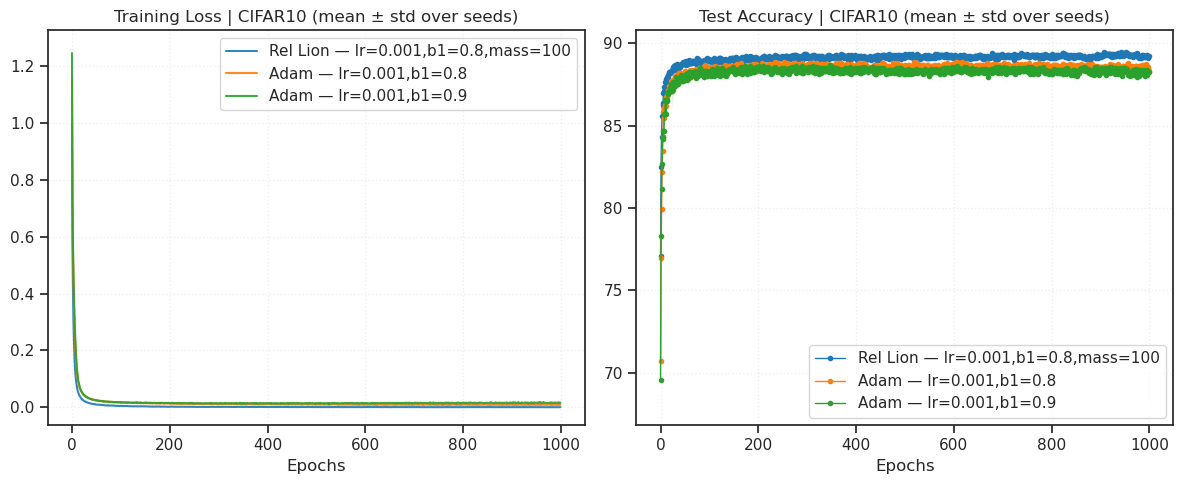

{'Adam — lr=0.001,b1=0.9': 88.22,
 'Adam — lr=0.001,b1=0.8': 88.45,
 'Rel Lion — lr=0.001,b1=0.8,mass=100': 89.08}